# The goal:

There are known to be CFT corrections to the things I've been calculating. I want to understand them!

Currently, it is known that 

$$-\log(P_l)=a_1 l + b_0 \log(L)+f(l/L)+a_0+...$$


It is interesting to consider if the form of the correlation function will be:

$$-\log(P_l(0)P_l(r)=a_1 2*l+b_0 \log(L)+f(l/L,l/r,r/L)+a_0'$$


We may need to use a different formula for some things. Let's just see!

In [1]:
import sys 

sys.path.append("../../src")

from common_imports import *
from equilibrium_z_projectors import *

import kblock_ising_model as kb

In [2]:
def P_p(l, L):
    """
    Equation (28) from the emptiness paper.

    Parameters
    ----------
    l : int
        Length of the interval (number of sites).
    L : int
        Total system size (circumference).

    Returns
    -------
    float
        Emptiness formation probability P_p.
    """
    M = np.zeros((l, l), dtype=np.complex128)  # matrix is Hermitian so real, but use complex128 for safety
    for i in range(l):
        for j in range(l):
            delta = 1.0 if i == j else 0.0
            M[i, j] = delta/2.0 + (1.0/(2*L)) * 1.0/np.sin(np.pi*(i-j+0.5)/L)
    return np.linalg.det(M).real  # imaginary part should vanish


# Scaling with $n$ only

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


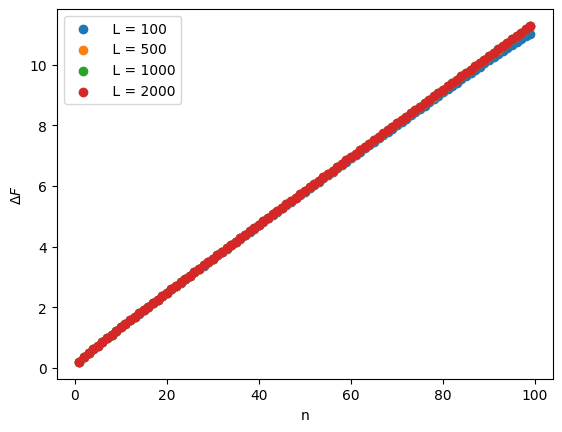

In [3]:
###Thermodynamic limit
Ls = [100,500,1000,2000]
L_max = 100
for L in Ls:
    ns = np.arange(1,L_max)
    data= [P_p(n,L) for n in ns]
    label = f" L = {L}"

    data= np.array(data)
    scatter(ns,-log(data),label=label)
    ylabel(r"$\Delta F$")
    xlabel(r"$\frac{n}{L}$")
    xlabel(r"n")
legend()

100%|██████████| 199/199 [00:01<00:00, 186.44it/s]


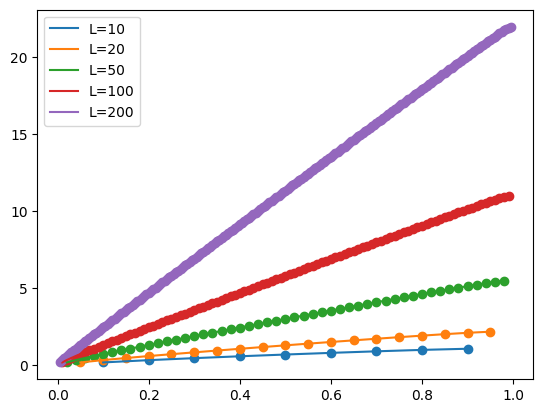

In [5]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def prediction(n, a1, ap, L):
    c = 1/2
    return a1*n + c/8*np.log(L/np.pi) + c/8*np.log(np.sin(np.pi*n/L)) + ap

Ls = [10,20,50,100,200]
fits =[]
for L in Ls:
    ns = np.arange(1, L)   # avoid n=0 to prevent log(0)
    data = np.array([P_p(n,L) for n in tqdm(ns)])
    E_p = -np.log(data)

    # wrapper with L fixed
    def pred_fixed(n, a1, ap):
        return prediction(n, a1, ap, L)

    popt, pcov = curve_fit(pred_fixed, ns, E_p)
    fits.append(popt)
    plt.plot(ns/L, E_p, label=f"L={L}")
    plt.scatter(ns/L,pred_fixed(ns,*popt))

plt.legend()
plt.show()


In [6]:
fits

[array([0.11098119, 0.08584613]),
 array([0.11061855, 0.08687115]),
 array([0.11022816, 0.08911836]),
 array([0.11010314, 0.09077917]),
 array([0.11005306, 0.09214302])]

In [7]:
for fit in fits:
    print(1/fit[1])

11.648748254158592
11.511301871176471
11.221031768129333
11.015743404161427
10.852693584568959


In [8]:
C=  0.915965594177219015054603514932384110774
a1= log(2)-2*C/pi
ap = 0.0951599254

100%|██████████| 10/10 [00:00<00:00, 96.36it/s]


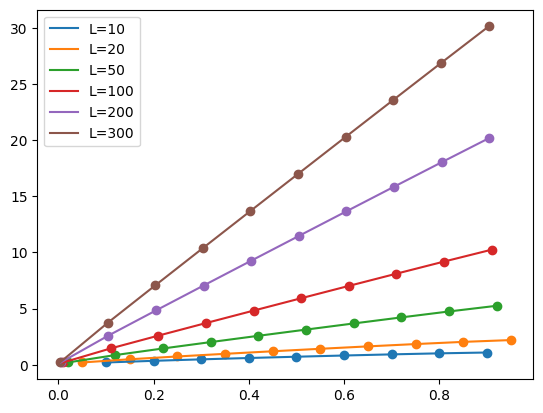

In [9]:


def prediction(n, a1, ap, L):
    c = 1/2
    return a1*n + c/8*np.log(L/np.pi) + c/8*np.log(np.sin(np.pi*n/L)) + ap

Ls = [10,20,50,100,200,300]
for L in Ls:
    ns = np.arange(1, L,L//10)   # avoid n=0 to prevent log(0)
    data = np.array([P_p(n,L) for n in tqdm(ns)])
    E_p = -np.log(data)

    # wrapper with L fixed
    def pred_fixed(n, a1, ap):
        return prediction(n, a1, ap, L)

   # popt, pcov = curve_fit(pred_fixed, ns, E_p)
    #fits.append(popt)
    plt.plot(ns/L, E_p, label=f"L={L}")
    plt.scatter(ns/L,pred_fixed(ns,a1,ap))
    

plt.legend()
plt.show()


100%|██████████| 299/299 [00:03<00:00, 84.05it/s]


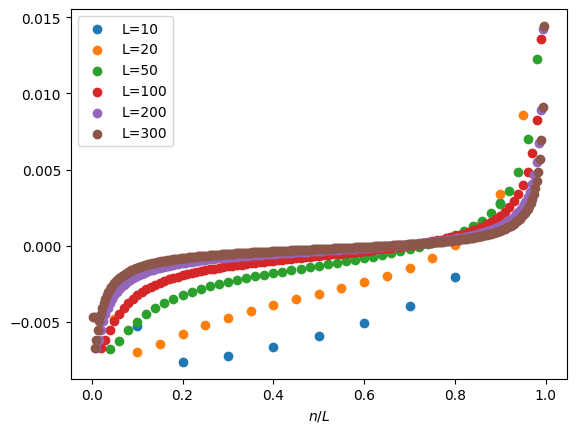

In [10]:


def prediction(n, a1, ap, L):
    c = 1/2
    return a1*n + c/8*np.log(L/np.pi) + c/8*np.log(np.sin(np.pi*n/L)) + ap

Ls = [10,20,50,100,200,300]
for L in Ls:
    ns = np.arange(1, L)   # avoid n=0 to prevent log(0)
    data = np.array([P_p(n,L) for n in tqdm(ns)])
    E_p = -np.log(data)

    # wrapper with L fixed
    def pred_fixed(n, a1, ap):
        return prediction(n, a1, ap, L)

   # popt, pcov = curve_fit(pred_fixed, ns, E_p)
    #fits.append(popt)
   # plt.plot(ns/L, E_p, label=f"L={L}")
    scatter(ns/L,(E_p-pred_fixed(ns,a1,ap)),label=f"L={L}")
xlabel(r"$n/L$")

legend()
show()


In the $L/l \to \infty$ limit this is supposed to look like

$$\epsilon_p = a_1 n + a_0^p+ \frac{c}{8} \log(n)- \frac{\xi c }{8 \pi } \log(n)/n$$

In [38]:
ns = np.arange(1,14)

Ps = np.array([P_n(n) for n in ns])
Eps = -log(Ps)

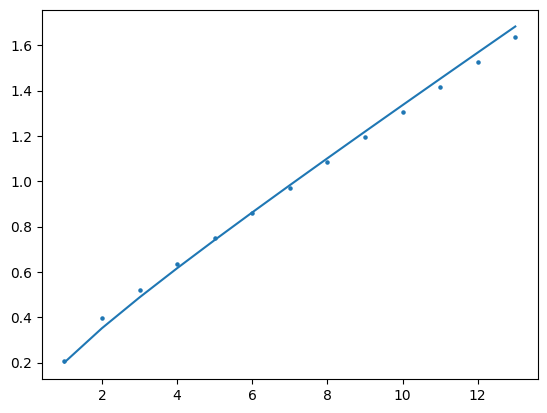

In [62]:
plot(ns,Eps)
scatter(ns, a1*ns+log(ns)/32+ap+1/6*log(ns)/ns,s=5)

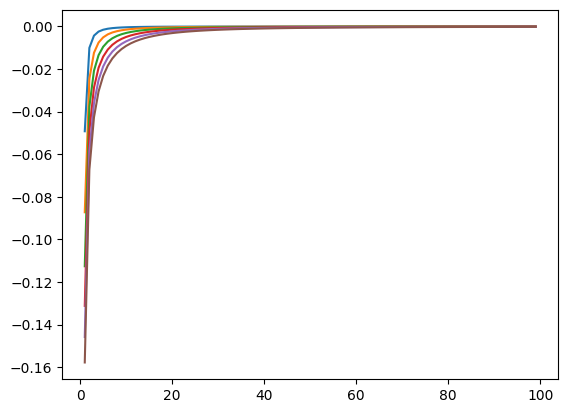

In [43]:
ns = np.arange(1,7) 

Rs = np.arange(1,100,1)

dat = []
for n in ns:
    data = np.array([P_n_correlations(n,r)/(P_n(n)**2) for r in Rs])
    E= -log(data)
    plot((Rs),E,label=n)
    dat.append(E)
dat=np.array(dat)




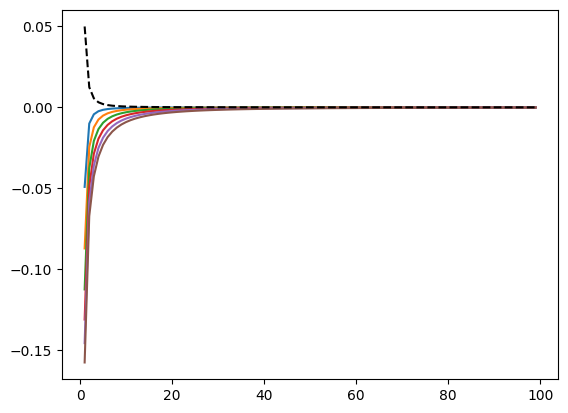

In [66]:
plot(Rs,dat.T)
plot(Rs,Rs**(-2.0)/20,"--k")
#loglog()

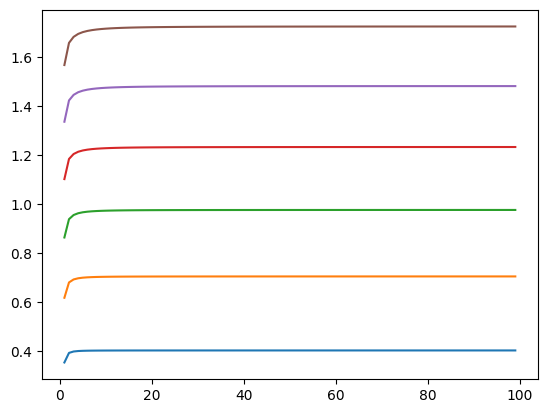

In [67]:
ns = np.arange(1,7) 

Rs = np.arange(1,100,1)

dat = []
for n in ns:
    data = np.array([P_n_correlations(n,r) for r in Rs])
    E= -log(data)
    plot((Rs),E,label=n)
    dat.append(E)
dat=np.array(dat)




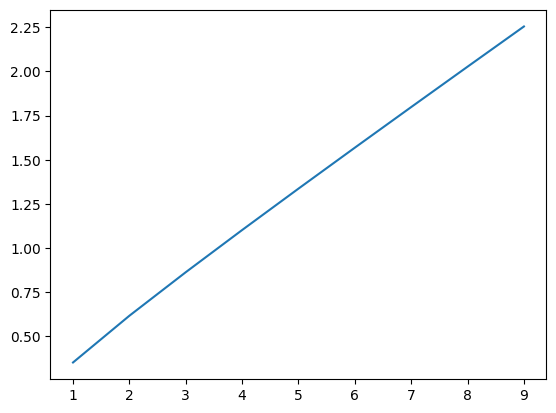

In [96]:
ns = np.arange(1,10) 

Rs = np.arange(1,100,1)

data = np.array([P_n_correlations(ni,1) for ni in ns])
E= -log(data)
plot((ns),E,label=n)





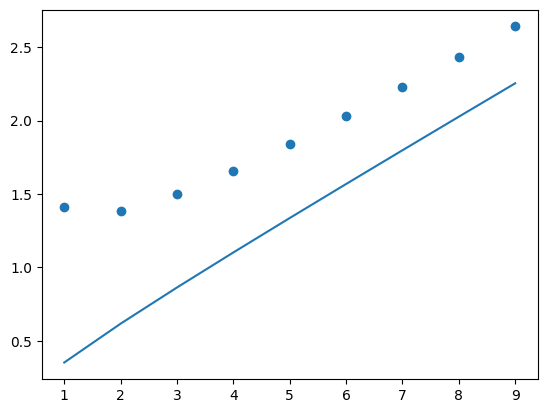

In [117]:
plot(ns,E)
scatter(ns,2*ns*a1+2*ap+1/16*log(ns)+1/sqrt(ns))